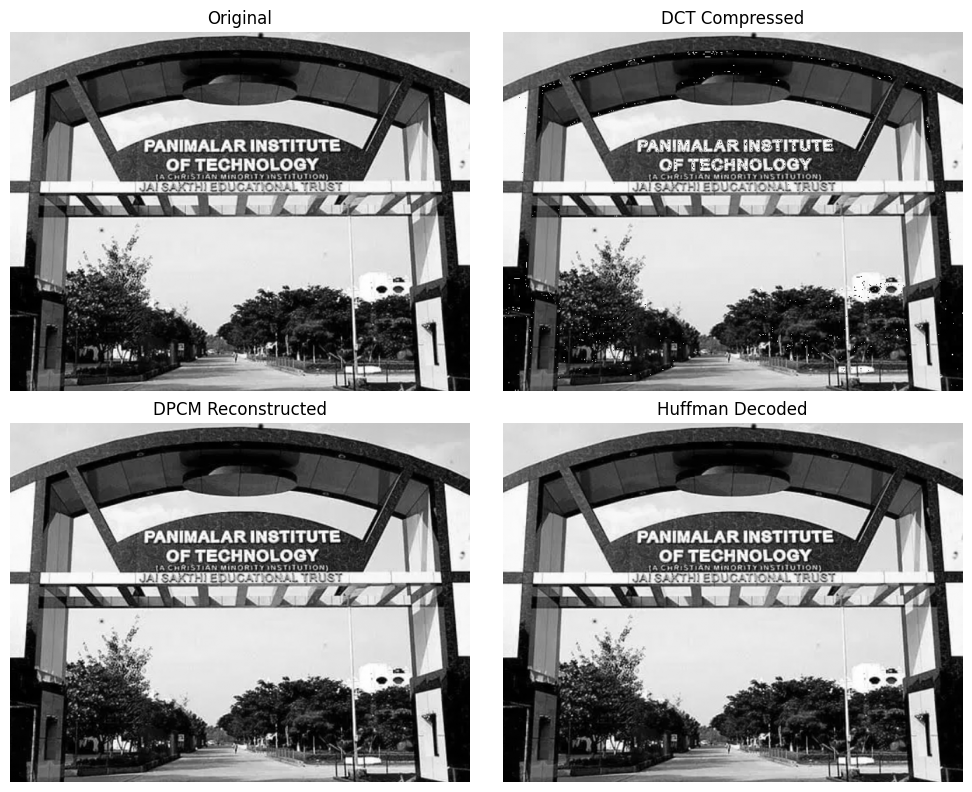

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import heapq

image = cv2.imread("test6.PNG")
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

h, w = gray.shape
h = h - h % 8
w = w - w % 8
gray = gray[:h, :w]

def dct2(block):
    return cv2.dct(np.float32(block))

def idct2(block):
    return cv2.idct(block)

dct_image = np.zeros_like(gray, dtype=np.float32)

for i in range(0, h, 8):
    for j in range(0, w, 8):
        block = gray[i:i+8, j:j+8]
        dct_block = dct2(block)
        dct_block[np.abs(dct_block) < 10] = 0
        dct_image[i:i+8, j:j+8] = idct2(dct_block)

dct_image = np.uint8(dct_image)

dpcm = np.zeros_like(gray, dtype=np.int16)
recon = np.zeros_like(gray, dtype=np.int16)

for i in range(h):
    for j in range(w):
        if j == 0:
            pred = 0
        else:
            pred = recon[i, j-1]
        dpcm[i, j] = gray[i, j] - pred
        recon[i, j] = pred + dpcm[i, j]

recon = np.uint8(np.clip(recon, 0, 255))

flat = gray.flatten()
freq = Counter(flat)

class Node:
    def __init__(self, value, freq):
        self.value = value
        self.freq = freq
        self.left = None
        self.right = None
    def __lt__(self, other):
        return self.freq < other.freq

heap = [Node(val, fr) for val, fr in freq.items()]
heapq.heapify(heap)

while len(heap) > 1:
    n1 = heapq.heappop(heap)
    n2 = heapq.heappop(heap)
    merged = Node(None, n1.freq + n2.freq)
    merged.left = n1
    merged.right = n2
    heapq.heappush(heap, merged)

root = heap[0]
codes = {}

def generate_codes(node, code=""):
    if node is None:
        return
    if node.value is not None:
        codes[node.value] = code
    generate_codes(node.left, code + "0")
    generate_codes(node.right, code + "1")

generate_codes(root)

encoded = ''.join([codes[p] for p in flat])

decoded = []
node = root
for bit in encoded:
    if bit == '0':
        node = node.left
    else:
        node = node.right
    if node.value is not None:
        decoded.append(node.value)
        node = root

decoded_image = np.array(decoded).reshape(gray.shape).astype(np.uint8)

plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
plt.title("Original")
plt.imshow(gray, cmap='gray')
plt.axis('off')

plt.subplot(2,2,2)
plt.title("DCT Compressed")
plt.imshow(dct_image, cmap='gray')
plt.axis('off')

plt.subplot(2,2,3)
plt.title("DPCM Reconstructed")
plt.imshow(recon, cmap='gray')
plt.axis('off')

plt.subplot(2,2,4)
plt.title("Huffman Decoded")
plt.imshow(decoded_image, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

Original 8x8 block:
222 221 221 220 220 220 220 220
221 221 221 220 220 220 220 220
221 221 220 221 221 221 221 221
220 221 220 221 221 221 221 221
220 220 220 221 221 221 222 222
220 220 220 221 221 222 222 222
220 220 220 221 221 222 222 222
219 220 220 220 220 221 221 221


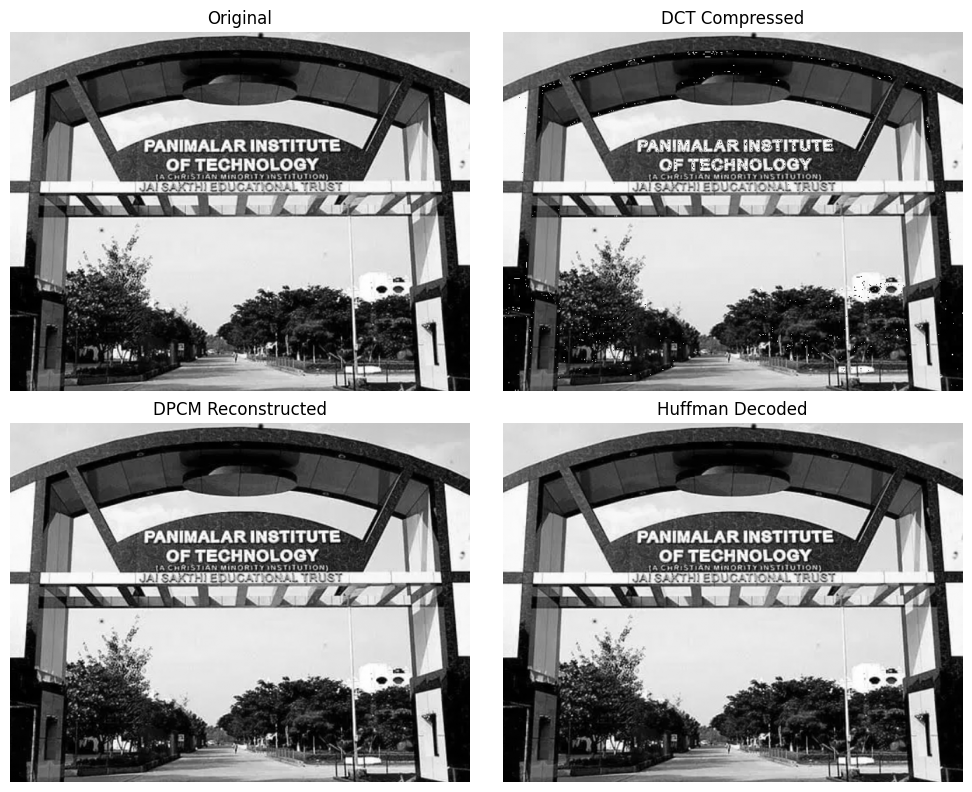

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import heapq

image = cv2.imread("test6.png")
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

h, w = gray.shape
h = h - h % 8
w = w - w % 8
gray = gray[:h, :w]

block8 = gray[0:8, 0:8]
print("Original 8x8 block:")
for row in block8:
    print(' '.join(map(str, row)))

def dct2(block):
    return cv2.dct(np.float32(block))

def idct2(block):
    return cv2.idct(block)

dct_image = np.zeros_like(gray, dtype=np.float32)

for i in range(0, h, 8):
    for j in range(0, w, 8):
        block = gray[i:i+8, j:j+8]
        dct_block = dct2(block)
        dct_block[np.abs(dct_block) < 10] = 0
        dct_image[i:i+8, j:j+8] = idct2(dct_block)

dct_image = np.uint8(dct_image)

dpcm = np.zeros_like(gray, dtype=np.int16)
recon = np.zeros_like(gray, dtype=np.int16)

for i in range(h):
    for j in range(w):
        if j == 0:
            pred = 0
        else:
            pred = recon[i, j-1]
        dpcm[i, j] = gray[i, j] - pred
        recon[i, j] = pred + dpcm[i, j]

recon = np.uint8(np.clip(recon, 0, 255))

flat = gray.flatten()
freq = Counter(flat)

class Node:
    def __init__(self, value, freq):
        self.value = value
        self.freq = freq
        self.left = None
        self.right = None
    def __lt__(self, other):
        return self.freq < other.freq

heap = [Node(val, fr) for val, fr in freq.items()]
heapq.heapify(heap)

while len(heap) > 1:
    n1 = heapq.heappop(heap)
    n2 = heapq.heappop(heap)
    merged = Node(None, n1.freq + n2.freq)
    merged.left = n1
    merged.right = n2
    heapq.heappush(heap, merged)

root = heap[0]
codes = {}

def generate_codes(node, code=""):
    if node is None:
        return
    if node.value is not None:
        codes[node.value] = code
    generate_codes(node.left, code + "0")
    generate_codes(node.right, code + "1")

generate_codes(root)

encoded = ''.join([codes[p] for p in flat])

decoded = []
node = root
for bit in encoded:
    if bit == '0':
        node = node.left
    else:
        node = node.right
    if node.value is not None:
        decoded.append(node.value)
        node = root

decoded_image = np.array(decoded).reshape(gray.shape).astype(np.uint8)

plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
plt.title("Original")
plt.imshow(gray, cmap='gray')
plt.axis('off')

plt.subplot(2,2,2)
plt.title("DCT Compressed")
plt.imshow(dct_image, cmap='gray')
plt.axis('off')

plt.subplot(2,2,3)
plt.title("DPCM Reconstructed")
plt.imshow(recon, cmap='gray')
plt.axis('off')

plt.subplot(2,2,4)
plt.title("Huffman Decoded")
plt.imshow(decoded_image, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()